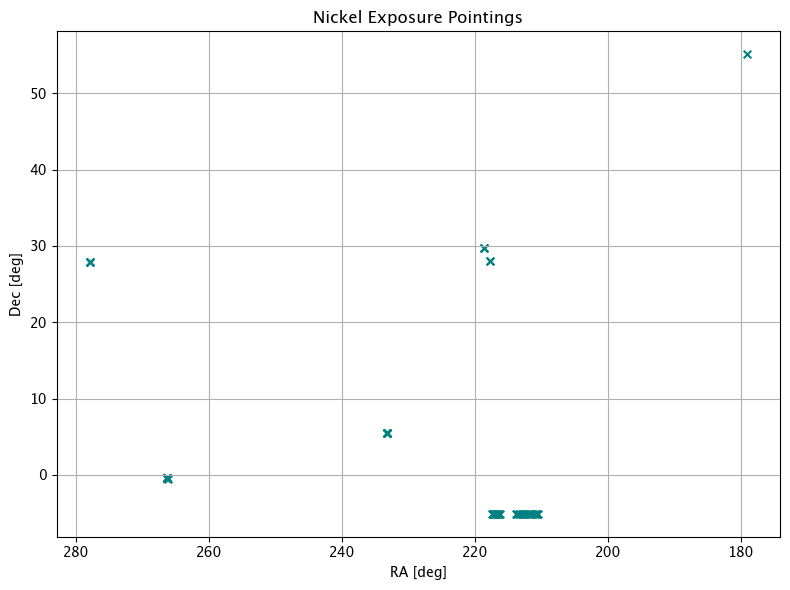

In [23]:
import matplotlib.pyplot as plt

# These are the column indexes for RA and Dec in the lines, based on your preview:
RA_COL = 15
DEC_COL = 16

ras = []
decs = []

with open("../../refcats/nickel_pointings.txt", "r") as f:
    for line in f:
        if line.strip().startswith("instrument") or line.strip().startswith("-----") or line.strip() == "":
            continue  # Skip header/blank lines
        fields = line.split()
        if len(fields) <= max(RA_COL, DEC_COL):
            continue  # Skip malformed lines
        try:
            ra = float(fields[RA_COL])
            dec = float(fields[DEC_COL])
            ras.append(ra)
            decs.append(dec)
        except ValueError:
            continue  # Skip non-numeric entries

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(ras, decs, s=30, color="teal", marker="x")
plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title("Nickel Exposure Pointings")
plt.grid(True)
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()


In [24]:
print(f"RA:  {min(ras):.2f}° – {max(ras):.2f}°")
print(f"Dec: {min(decs):.2f}° – {max(decs):.2f}°")


RA:  179.12° – 277.92°
Dec: -5.11° – 55.13°


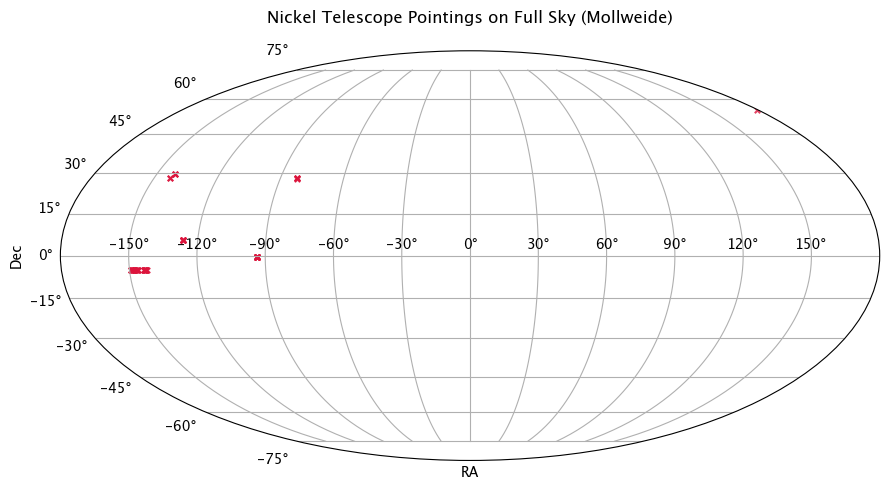

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# If you already have ras and decs as lists:
ras = np.array(ras)   # convert to NumPy arrays
decs = np.array(decs)

# Convert RA from [0, 360] to [-180, 180] for Mollweide
ras_wrapped = np.remainder(ras + 180, 360) - 180
ras_rad = np.radians(ras_wrapped)
decs_rad = np.radians(decs)

# Plot
plt.figure(figsize=(10, 5))
ax = plt.subplot(111, projection="mollweide")
ax.scatter(ras_rad, decs_rad, s=15, color="crimson", marker="x", alpha=0.8)

ax.grid(True)
ax.set_title("Nickel Telescope Pointings on Full Sky (Mollweide)", pad=20)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
plt.tight_layout()
plt.show()


In [ ]:
'../../refcats/

In [36]:
import astropy.io.ascii
data = astropy.io.ascii.read('../../refcats/scripts/gaia_dr3_cones/gaia_dr3_all_cones.csv', format='csv')
print(data)


     source_id              ra         ... phot_rp_mean_mag    ruwe   
------------------- ------------------ ... ---------------- ----------
 840922676360354432 179.03219728427678 ...        19.262377  1.0469292
 840922813799308928 178.98065020337995 ...         19.53982  1.0467491
 840923917606800256 178.98200944657998 ...        19.754118         --
 840924020685381760 179.00244655688445 ...        20.139591         --
 840923574009207040 178.98964881899116 ...       15.3648815 0.99501926
 840923638433042816 178.98110674892496 ...         19.91908  1.0124224
 840923672793509632 178.99839903616316 ...        19.499014  1.2321254
 840923672793513984 179.00526768343542 ...        19.209797  1.1480147
 840923711448229120  179.0215643536737 ...        19.410604  1.0600246
 840923741512257408 178.99498932435753 ...        17.535273  1.0824534
                ...                ... ...              ...        ...
4585700920832176640 277.61438549172897 ...        14.769891  0.9807427
458570